In [1]:
import torch
import torch.nn as nn

from torch.utils.data import DataLoader

from torchvision import datasets, transforms


Load Dataset

In [2]:
train_transforms = transforms.Compose([
       transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),

])

val_test_transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [26]:
train_dataset = datasets.ImageFolder(root='../datasets/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train', transform=train_transforms)
valid_dataset=datasets.ImageFolder(root="../datasets/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid",transform=val_test_transform)
test_dataset=datasets.ImageFolder(root="../datasets/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid",transform=val_test_transform)

In [27]:
train_data=DataLoader(train_dataset,batch_size=32,shuffle=True)
valid_data=DataLoader(valid_dataset,batch_size=32,shuffle=False)
test_data=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [25]:
print(test_dataset.classes)

['test']


Model training

In [5]:
from torchvision import models
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_classes=len(train_dataset.classes)

print(num_classes)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

38


Training setup

In [6]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

Training Loop

In [7]:
device = torch.device( "cpu")
model.to(device)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [8]:
print(device)

cpu


In [9]:
for epoch in range(20):
    model.train()
    train_loss = 0

    for images,labels in train_data:
        images,labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    print(f"Epoch:{epoch+1}, Loss:{train_loss/len(train_data)}")







Epoch:1, Loss:1.8818751753977228
Epoch:2, Loss:0.8451857036170386
Epoch:3, Loss:0.6253637151116939
Epoch:4, Loss:0.5265735561095101
Epoch:5, Loss:0.4686380869280386
Epoch:6, Loss:0.4258686466533377
Epoch:7, Loss:0.3938531307575645
Epoch:8, Loss:0.3730790528163999
Epoch:9, Loss:0.352337011401904
Epoch:10, Loss:0.3351598799391448
Epoch:11, Loss:0.3222528221318816
Epoch:12, Loss:0.308664854007197
Epoch:13, Loss:0.3023109359731987
Epoch:14, Loss:0.2935738493881282
Epoch:15, Loss:0.28819109865709713
Epoch:16, Loss:0.2787812574612698
Epoch:17, Loss:0.2716954597829416
Epoch:18, Loss:0.26499774405358867
Epoch:19, Loss:0.26042869736762225
Epoch:20, Loss:0.2569871878198021


Validation

In [10]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images,labels in valid_data:
        images,labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print("Validation accuracy", correct / total)

Validation accuracy 0.9537332119280674


Confusion matrix and classification Report

In [30]:
all_preds=[]
all_labels=[]

with torch.no_grad():
    for images,labels in test_data:
        images,labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())



In [31]:
print(test_dataset.classes)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

Confusion matrix [[477   1   0 ...   0   0   1]
 [  1 488   2 ...   0   0   0]
 [  0   0 435 ...   1   0   0]
 ...
 [  0   0   0 ... 480   2   0]
 [  0   0   0 ...   2 427   0]
 [  0   0   0 ...   0   1 467]]


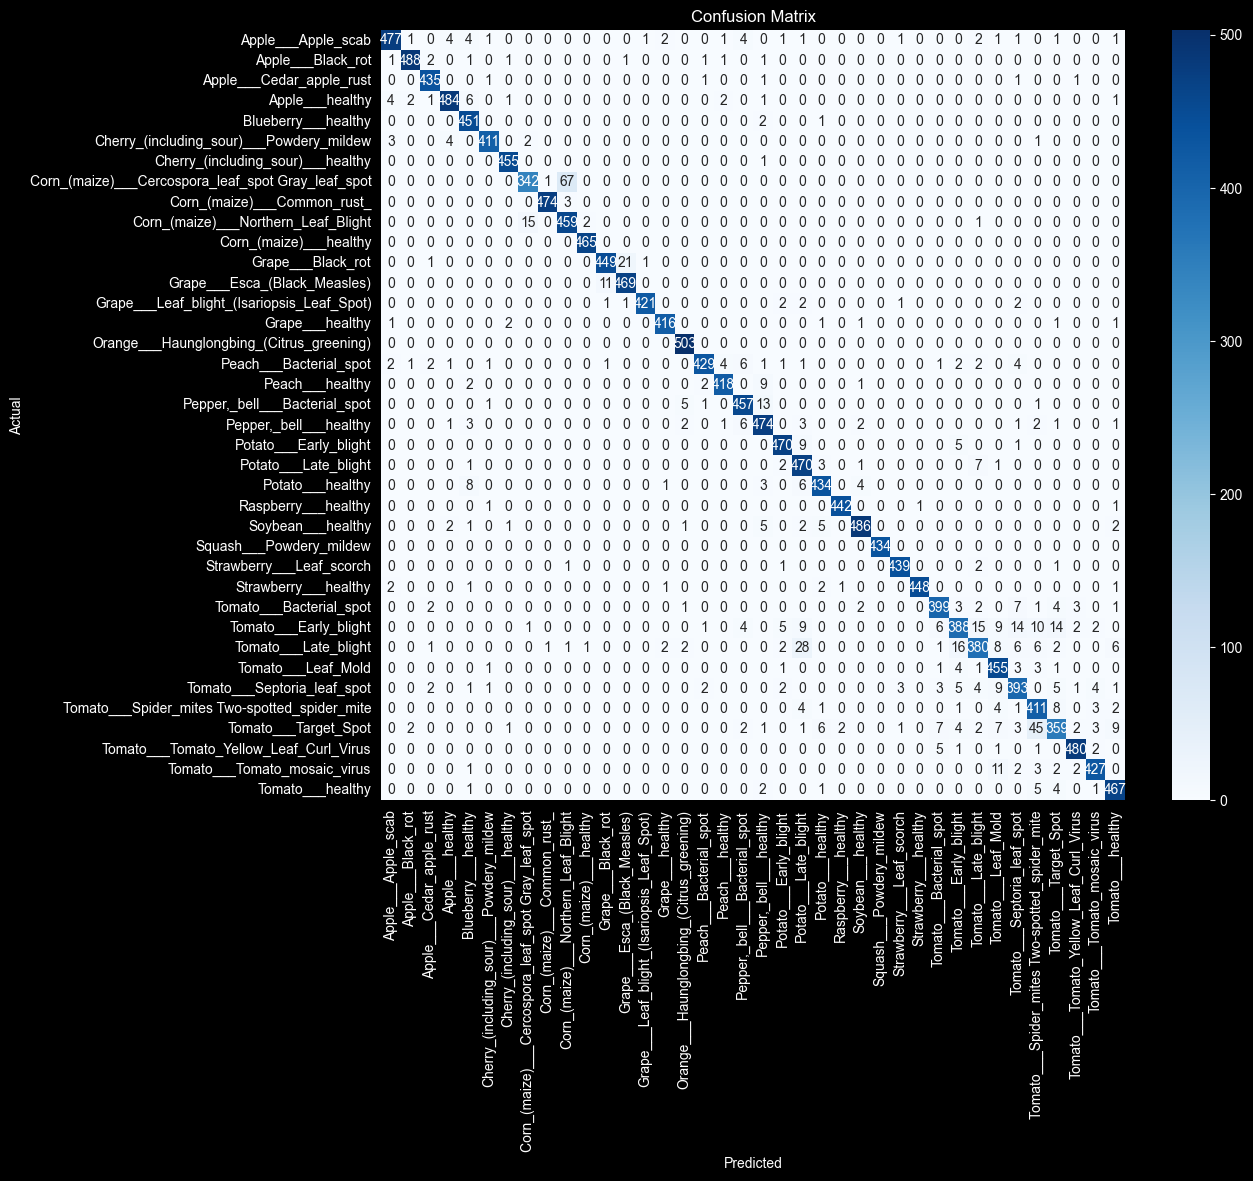

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix",confusion_matrix(all_labels, all_preds))
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [33]:
from sklearn.metrics import classification_report
cm=classification_report(all_labels, all_preds,target_names=test_dataset.classes)
print("Classificationn Report",cm)

Classificationn Report                                                     precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.95      0.96       504
                                 Apple___Black_rot       0.99      0.98      0.98       497
                          Apple___Cedar_apple_rust       0.98      0.99      0.98       440
                                   Apple___healthy       0.98      0.96      0.97       502
                               Blueberry___healthy       0.94      0.99      0.96       454
          Cherry_(including_sour)___Powdery_mildew       0.98      0.98      0.98       421
                 Cherry_(including_sour)___healthy       0.99      1.00      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.83      0.89       410
                       Corn_(maize)___Common_rust_       1.00      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight      

In [11]:
torch.save(model.state_dict(), "plant_disease_model.pth")

Predict the image

In [50]:
model=models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
num_classes=len(train_dataset.classes)
model.classifier[1]=nn.Linear(model.classifier[1].in_features, num_classes)

model.load_state_dict(torch.load("plant_disease_model.pth",map_location=torch.device('cpu')))
model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [51]:
transforms_predict_image=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [52]:
from PIL import Image
def predict_image(img_path,model,classes):
    image=Image.open(img_path).convert("RGB")
    input_tensor=transforms_predict_image(image).unsqueeze(0)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs=torch.softmax(outputs, dim=1)
        confidence,pred=torch.max(probs,1)

    return classes[pred.item()],confidence.item()

In [56]:
class_names=train_dataset.classes

label,confidence=predict_image("../test/test/CornCommonRust1.JPG",model,class_names)
print("Prediction",label,"\n Confidence:",confidence)


Prediction Corn_(maize)___Common_rust_ 
 Confidence: 0.998505711555481
